# Методы отбора признаков в хемоинформатике

In [1]:
from rdkit.Chem import Draw

from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import MACCSkeys
from rdkit.Chem import PandasTools

from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

IPythonConsole.ipython_useSVG = True

import pandas as pd
import numpy as np

from rdkit import RDLogger
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [ ]:
# эта клетка только для демонстрации, её НЕ НУЖНО запускать
# ниже производится загрузка полученного таким образом датасета
def RDkit_descriptors(smiles):
    mols = [Chem.MolFromSmiles(i) for i in smiles]
    
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    desc_names = calc.GetDescriptorNames()
    
    Mol_descriptors = []
    
    for mol in mols:
        mol = Chem.AddHs(mol)
        descriptors = calc.CalcDescriptors(mol)  
        Mol_descriptors.append(descriptors)
        
    return Mol_descriptors, desc_names 


df = pd.read_csv('QM9/raw/gdb9.sdf.csv')
new_df = PandasTools.LoadSDF('QM9/raw/gdb9.sdf', embedProps=True, molColName=None, smilesName='smiles')

# Объединяем датафреймы
qm9_df = df.rename(columns={"mol_id": "ID"})
qm9_df = pd.merge(qm9_df, new_df, on="ID")

rdkit_descriptors_list, descriptor_names = RDkit_descriptors(qm9_df['smiles'].tolist())

rdkit_df = pd.DataFrame(rdkit_descriptors_list, columns=descriptor_names)

rdkit_df = rdkit_df.replace([np.inf, -np.inf], np.nan).dropna(axis=1, how='any')

merged_df = pd.concat([qm9_df, rdkit_df], axis=1)

# Сохранение в CSV
merged_df.to_csv("qm_9_rdkit_featurized.csv", index=False)

In [3]:
#используйте эту клетку для загрузки датасета
merged_df = pd.read_csv("qm_9_rdkit_featurized.csv")

In [4]:
original_cols = ['ID', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve',
       'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom',
       'g298_atom', 'smiles']
feature_df = merged_df.drop(columns = original_cols)

In [5]:
feature_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR
0,5.937500,5.937500,2.500000,-2.500000,0.359785,64.000000,16.043,12.011,16.031300,8,...,0,0,0,0,0,0,0,0,0.63610,6.7310
1,5.750000,5.750000,0.250000,-0.250000,0.397555,39.000000,17.031,14.007,17.026549,8,...,1,1,1,0,0,0,0,0,0.16200,5.0221
2,5.375000,5.375000,2.750000,2.750000,0.327748,20.000000,18.015,15.999,18.010565,8,...,0,0,1,0,0,0,0,0,-0.82470,3.6138
3,5.902778,5.902778,1.597222,1.597222,0.332926,8.000000,26.038,24.022,26.015650,10,...,0,0,0,0,0,0,0,0,0.24940,9.8900
4,6.986111,6.986111,1.000000,1.000000,0.369797,4.500000,27.026,26.018,27.010899,10,...,1,0,1,0,0,0,0,0,0.13978,6.6700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133242,8.343750,8.343750,1.357639,-2.625694,0.419962,175.111111,120.175,110.095,120.080776,46,...,0,1,1,0,3,5,8,8,-0.95590,30.9737
133243,8.218750,8.218750,1.916667,-2.210417,0.455786,166.222222,120.151,112.087,120.057515,46,...,1,0,1,0,6,2,8,8,0.64950,29.6710
133244,8.315972,8.315972,1.501597,-2.676042,0.305840,175.111111,122.171,112.091,122.083301,46,...,0,2,2,0,1,7,8,8,-3.71500,29.2444
133245,8.331597,8.331597,1.485972,-2.613542,0.413790,175.111111,120.175,110.095,120.080776,46,...,0,1,1,0,4,4,8,8,-1.09840,30.9257


## Классические статистические методы

### Фильтр константных признаков

In [9]:
# Рассчитываем дисперсию для каждого признака
variances = feature_df.var()
# Находим признаки с нулевой дисперсией (абсолютно постоянные)
constant_features = variances[variances == 0].index.tolist()
print(f"Найдено постоянных признаков: {len(constant_features)}")
if constant_features:
    print(f"Список: {constant_features}")

Найдено постоянных признаков: 5
Список: ['SMR_VSA8', 'SlogP_VSA12', 'SlogP_VSA9', 'EState_VSA11', 'VSA_EState10']


### Фильтр слабо варьирующихся признаков

In [12]:
def near_constant_features(df, threshold=0.90):
    """Находит признаки, где доля самого частого значения превышает порог."""
    near_constant = []
    for col in df.columns:
        most_common_freq = df[col].value_counts(normalize=True).iloc[0]
        if most_common_freq >= threshold:
            near_constant.append(col)
    return near_constant

near_constant = near_constant_features(feature_df, threshold=0.90)
for x in constant_features:
    near_constant.remove(x)

### Фильтр сильно скоррелированных параметров

In [16]:
def remove_highly_correlated(df, method = 'pearson', threshold=0.85):
    corr_matrix = df.corr(method = method).abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return to_drop

columns_to_drop = remove_highly_correlated(feature_df, threshold=0.85)

In [18]:
minimal_preprocessing = feature_df.drop(columns=constant_features)

__Замечание__

На клетке выше заканчивается "традиционный пайплайн", который я использую в 90% задач по QSAR и подобному анализу. Про анализ важностей признаков мы поговорим отдельно в конце курса - для таких применений, конечно, количество признаков нередко приходится снижать дальше. Пока рассмотрим алгоритмы снижения размерности только с практической стороны - качества обученной baseline модели (XGBoost).

Чтобы лучше промоделировать реальную задачу, для остальных методов мы ограничимся отбором только неконстантных признаков (minimal_preprocessing), вдруг какой-то из методов сможет извлечь что-то полезное из признаков, которые в "традиционном" пайплайне мы удаляли.

## Формирование стандартного пайплайна

Разделение выборки на трейн и тест для проверки качества модели

In [26]:
# Разделение данных на train/test
from sklearn.model_selection import train_test_split

# Целевая переменная
target = merged_df['homo']

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    minimal_preprocessing, 
    target,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Размер train набора: {X_train.shape}")
print(f"Размер test набора: {X_test.shape}")

Размер train набора: (106597, 120)
Размер test набора: (26650, 120)


Необходимые импорты и глобальные переменные (N_FEATURES_TO_SELECT)

In [29]:
# Методы отбора признаков
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_regression,
    mutual_info_regression,
    RFE
)
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.decomposition import PCA, FastICA
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
N_FEATURES_TO_SELECT = minimal_preprocessing.shape[1] - len(near_constant + columns_to_drop)
# Фиксированное количество признаков для методов, которые этого требуют
#Этот параметр можно менять, но для наглядности я предлагаяю его взять равным результату для classical_preprocessing

Функция обучения XGBoost

In [32]:
def train_and_evaluate(method_name, X_train_selected, X_test_selected):
    """
    Обучает XGBoost модель и оценивает качество на holdout тесте.
    
    Параметры:
    - method_name: название метода отбора признаков
    - X_train_selected: тренировочные данные после отбора признаков
    - X_test_selected: тестовые данные после отбора признаков
    
    Возвращает: словарь с метриками качества
    """
    # Фиксированные гиперпараметры XGBoost
    model = xgb.XGBRegressor(
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        n_estimators=200,
        random_state=RANDOM_STATE,
        verbosity=0,
        eval_metric='rmse'
    )
    
    # Обучение
    model.fit(X_train_selected, y_train, verbose=False)
    
    # Предсказание на тесте
    y_pred = model.predict(X_test_selected)
    
    # Расчёт метрик
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_squared_error(y_test, y_pred, squared=True)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{method_name:40s} | Признаков: {X_train_selected.shape[1]:3d} | "
          f"RMSE: {rmse:.6f} | R²: {r2:.4f}")
    
    return {
        'method': method_name,
        'n_features': X_train_selected.shape[1],
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

Тестирование каждого метода предобработки, начиная с классической

### 0. Фильтрация только константных признаков

In [36]:
results = []

# Базовый метод: используем признаки после классической предобработки
results.append(train_and_evaluate(
    "0. Минимальная предобработка",
    X_train,
    X_test
))

0. Минимальная предобработка             | Признаков: 120 | RMSE: 0.008024 | R²: 0.8696


### 1. Фильтрация практически константных и высокоскоррелированных признаков (наш бейзлайн)

In [40]:
results = []
X_train_сlassical = X_train.drop(columns= near_constant + columns_to_drop)
X_test_classical = X_test.drop(columns= near_constant + columns_to_drop)
# Базовый метод: используем признаки после классической предобработки
results.append(train_and_evaluate(
    "1. Классическая предобработка",
    X_train_сlassical,
    X_test_classical
))

1. Классическая предобработка            | Признаков:  72 | RMSE: 0.008277 | R²: 0.8612


### 2. VarianceThreshold - Фильтрация по дисперсии

#### Что делает
Удаляет признаки, которые почти не варьируются в данных (имеют низкую дисперсию). 
Признаки с постоянным или близким к постоянному значением не несут информации для модели.

#### Как работает
1. Вычисляет дисперсию для каждого признака
2. Сравнивает каждую дисперсию с заданным порогом (threshold)
3. Удаляет признаки, у которых дисперсия < threshold

Пример: если признак имеет значения [1.0, 1.0, 1.1, 1.0, 1.0], его дисперсия близка к 0, 
и он будет удален.

#### Когда использовать
- На первом этапе очистки для удаления явно бесполезных признаков
- Когда нужна скорость и простота
- Как предварительный фильтр перед другими методами
- Для быстрого прототипирования и исследования данных

In [42]:
import time
start_time = time.time()
thrs = 0.10
vt = VarianceThreshold(threshold=thrs)
X_train_vt = vt.fit_transform(X_train)
X_test_vt = vt.transform(X_test)

results.append(train_and_evaluate(
    f"2. VarianceThreshold (threshold={thrs})",
    X_train_vt,
    X_test_vt
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

2. VarianceThreshold (threshold=0.1)     | Признаков: 104 | RMSE: 0.008333 | R²: 0.8593
Время выполнения пайплайна - 1.268449068069458 секунд


### 3. SelectKBest (f_regression) - Отбор лучших K признаков по F-статистике

#### Что делает
Выбирает ровно K признаков, которые имеют наибольшую корреляцию с целевой переменной.
Использует F-статистику для оценки линейной зависимости между признаком и целевой переменной.

#### Как работает
1. Для каждого признака вычисляется F-статистика:
   F = (объясняемая дисперсия) / (необъясняемая дисперсия)
   
2. F-статистика показывает, насколько хорошо признак объясняет целевую переменную
   - Большое F значение = сильная линейная зависимость
   - Маленькое F значение = слабая зависимость

3. Признаки ранжируются по значению F-статистики в порядке убывания
4. Выбираются топ-K признаков
5. Остальные признаки отбрасываются

Пример: если признак X имеет F=150, а признак Y имеет F=5, 
то X сильнее коррелирует с целевой переменной и будет выбран раньше Y.

#### Когда использовать
- Когда есть основания полагать, что зависимость от целевой переменной линейная
- Когда нужна простая и быстрая интерпретируемая модель
- Для быстрого прототипирования и EDA (Exploratory Data Analysis)
- На хемоинформатике: когда видны линейные QSAR зависимости
- Для первичного отбора признаков перед более сложными методами

In [44]:
# SelectKBest: выбирает K признаков с наибольшей корреляцией с целевой переменной
# f_regression вычисляет значимость для регрессии
# Простой метод, быстрый и интерпретируемый
start_time = time.time()
skb_f = SelectKBest(score_func=f_regression, k=N_FEATURES_TO_SELECT)
X_train_skb_f = skb_f.fit_transform(X_train, y_train)
X_test_skb_f = skb_f.transform(X_test)

results.append(train_and_evaluate(
   f"3. SelectKBest (f_regression, {N_FEATURES_TO_SELECT})",
    X_train_skb_f,
    X_test_skb_f
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

3. SelectKBest (f_regression, 72)        | Признаков:  72 | RMSE: 0.008709 | R²: 0.8464
Время выполнения пайплайна - 0.9298050403594971 секунд


### 4. SelectKBest (mutual_info_regression) - Отбор по взаимной информации

#### Что делает
Выбирает K признаков на основе "взаимной информации" (Mutual Information).
Взаимная информация показывает, сколько информации один признак содержит о целевой переменной.

#### Как работает
1. Для каждого признака X и целевой переменной y вычисляется взаимная информация I(X; y)

2. I(X; y) показывает: сколько мы узнаём о y, зная X
   - I(X; y) = 0: X и y независимы (не связаны)
   - I(X; y) > 0: X содержит информацию о y
   - Формула: I(X; y) = Σ p(x, y) * log(p(x,y) / (p(x) * p(y)))

3. Признаки ранжируются по I(X; y) и выбираются топ-K

4. Ключевое отличие от f_regression: ловит НЕЛИНЕЙНЫЕ зависимости!

Пример: если X = [1,2,1,2,1,2] и y = [10,20,10,20,10,20],
то I(X; y) будет очень высокой, хотя линейная корреляция не очень сильная.

#### Когда использовать
- Когда подозреваются НЕЛИНЕЙНЫЕ зависимости
- На хемоинформатике: для молекулярных дескрипторов, которые часто нелинейно связаны с активностью
- Когда нужна более универсальная мера значимости признака
- На достаточно больших выборках (минимум 100+ примеров)
- Когда другие методы не работают хорошо
- Для захвата сложных паттернов в данных

In [46]:
# SelectKBest с mutual_info_regression: выбирает признаки на основе взаимной информации
# Может захватить нелинейные зависимости, которые f_regression не видит
start_time = time.time()
skb_mi = SelectKBest(score_func=mutual_info_regression, k=N_FEATURES_TO_SELECT)
X_train_skb_mi = skb_mi.fit_transform(X_train, y_train)
X_test_skb_mi = skb_mi.transform(X_test)

results.append(train_and_evaluate(
    f"4. SelectKBest (mutual_info, {N_FEATURES_TO_SELECT})",
    X_train_skb_mi,
    X_test_skb_mi
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

4. SelectKBest (mutual_info, 72)         | Признаков:  72 | RMSE: 0.008333 | R²: 0.8593
Время выполнения пайплайна - 54.7353789806366 секунд


### 5. RFE (LinearRegression) - Рекурсивное исключение признаков

#### Что делает
Итеративно обучает модель (LinearRegression), убирает признак с наименьшей важностью,
и повторяет процесс до тех пор, пока не останется нужное количество признаков.

#### Как работает
1. Начинают со ВСЕХ признаков

2. Обучают LinearRegression модель на этих признаках

3. Смотрят на коэффициенты (weights) в модели: чем меньше |coef|, тем признак менее важен

4. Удаляют признак с наименьшим |коэффициентом|

5. Повторяют шаги 2-4 до тех пор, пока не останется нужное количество признаков

Пример процесса:
- Итерация 1: 200 признаков → обучение → удаляют признак с coef=0.001
- Итерация 2: 199 признаков → обучение → удаляют признак с coef=0.005
- Итерация 3: 198 признаков → обучение → удаляют признак с coef=0.002
- ...
- Итерация 150: 50 признаков → СТОП (достигли целевого количества)

#### Когда использовать
- Когда есть время (RFE может быть долго)
- Когда данные уже подготовлены и масштабированы
- Для линейных моделей (когда будите использовать LinearRegression)
- На задачах, где нужна максимальная стабильность выбора
- Когда нужно понять относительную важность признаков в линейной модели
- На относительно небольших наборах данных (до 500 признаков)

In [48]:
# RFE (Recursive Feature Elimination): итеративно удаляет признаки с наименьшей значимостью
# Использует LinearRegression для оценки важности
# Требует масштабирования данных для корректной работы
start_time = time.time()
scaler_rfe_lr = StandardScaler()
X_train_scaled = scaler_rfe_lr.fit_transform(X_train)
X_test_scaled = scaler_rfe_lr.transform(X_test)

rfe_lr = RFE(
    estimator=LinearRegression(),
    n_features_to_select=N_FEATURES_TO_SELECT,
    step=0.1
)
X_train_rfe_lr = rfe_lr.fit_transform(X_train_scaled, y_train)
X_test_rfe_lr = rfe_lr.transform(X_test_scaled)

results.append(train_and_evaluate(
    f"5. RFE (LinearRegression, {N_FEATURES_TO_SELECT})",
    X_train_rfe_lr,
    X_test_rfe_lr
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

5. RFE (LinearRegression, 72)            | Признаков:  72 | RMSE: 0.008816 | R²: 0.8426
Время выполнения пайплайна - 1.5090346336364746 секунд


### 6. RFE (RandomForest) - Рекурсивное исключение с Random Forest

#### Что делает
Как RFE с LinearRegression, но вместо линейной модели использует RandomForest.
RandomForest может захватить НЕЛИНЕЙНЫЕ зависимости и взаимодействия между признаками.

#### Как работает
1. Начинают со ВСЕХ признаков

2. Обучают RandomForest модель

3. RandomForest вычисляет важность каждого признака (feature importance):
   - Смотрит: в скольких деревьях используется этот признак для разбиения
   - На какую величину каждый признак уменьшает ошибку (Gini/Entropy важность)

4. Удаляют признак с наименьшей важностью

5. Повторяют шаги 2-4

Ключевое отличие: RandomForest видит нелинейные зависимости, взаимодействия признаков,
а LinearRegression видит только линейные зависимости.

#### Когда использовать
- Когда данные содержат ЯВНЫЕ нелинейные зависимости
- На хемоинформатике: для молекулярных дескрипторов (часто нелинейно связаны с активностью)
- Когда есть время ждать (может быть долго на больших наборах)
- Когда нужна максимальная автоматизация без предположений о типе зависимости
- Для финального выбора признаков на больших данных
- Когда нужно захватить сложные взаимодействия

In [50]:
# RFE с RandomForest: итеративно удаляет признаки на основе важности в RandomForest
# Лучше захватывает нелинейные взаимодействия между признаками
start_time = time.time()
rfe_rf = RFE(
    estimator=RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    n_features_to_select=N_FEATURES_TO_SELECT,
    step=0.1
)
X_train_rfe_rf = rfe_rf.fit_transform(X_train, y_train)
X_test_rfe_rf = rfe_rf.transform(X_test)

results.append(train_and_evaluate(
    f"6. RFE (RandomForest, {N_FEATURES_TO_SELECT})",
    X_train_rfe_rf,
    X_test_rfe_rf
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

6. RFE (RandomForest, 72)                | Признаков:  72 | RMSE: 0.008120 | R²: 0.8664
Время выполнения пайплайна - 127.6444878578186 секунд


### 7. LassoCV - Регуляризация L1 (LASSO) с кросс-валидацией

#### Что делает
Обучает модель линейной регрессии с регуляризацией L1 (LASSO).
Регуляризация L1 штрафует большие коэффициенты и автоматически обнуляет некоторые из них.
Признаки с нулевыми коэффициентами удаляются (естественный отбор).
LassoCV автоматически подбирает силу регуляризации (параметр alpha) через кросс-валидацию.

#### Как работает
1. LASSO минимизирует целевую функцию:
   MSE(y, ŷ) + alpha * Σ|коэффициент|
   - Первая часть: обычная ошибка регрессии
   - Вторая часть: штраф за большие коэффициенты (регуляризация)
   - alpha - параметр, контролирующий силу штрафа

2. LassoCV пробует разные значения alpha и выбирает лучшее через кросс-валидацию

3. При большом alpha:
   - Сильный штраф на коэффициенты
   - Многие коэффициенты обнуляются → отбор признаков
   - Модель простая и интерпретируемая

4. При маленьком alpha:
   - Слабый штраф
   - Больше признаков остаются
   - Модель может переобучиться

Пример:
- alpha = 0.01: коэфф = [0.5, 0.0, 0.3, 0.0, 0.2] → 3 признака остаются
- alpha = 0.001: коэфф = [0.5, 0.1, 0.3, 0.15, 0.2] → 5 признаков остаются


#### Когда использовать
- Когда нужно ОДНОВРЕМЕННО обучить модель и отобрать признаки
- Для линейных QSAR моделей на хемоинформатике
- Когда важна интерпретируемость (простые линейные коэффициенты)
- Когда нужно автоматически отобрать признаки без ручного подбора K
- Для быстрого отбора и обучения
- Когда нужно понять, какие именно признаки используются моделью

In [51]:
# LassoCV: использует регрессию Lasso с кросс-валидацией для подбора силы регуляризации
# Признаки с нулевыми коэффициентами удаляются (естественный отбор)
# Требует масштабирования данных
start_time = time.time()
scaler_lasso = StandardScaler()
X_train_lasso_scaled = scaler_lasso.fit_transform(X_train)
X_test_lasso_scaled = scaler_lasso.transform(X_test)

lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000)
lasso.fit(X_train_lasso_scaled, y_train)

# Выбираем признаки с ненулевыми коэффициентами
selected_features_lasso = np.abs(lasso.coef_) > 1e-5
X_train_lasso = X_train_lasso_scaled[:, selected_features_lasso]
X_test_lasso = X_test_lasso_scaled[:, selected_features_lasso]

# Если слишком мало признаков выбрано, берём топ-50 по значимости
if X_train_lasso.shape[1] < 10:
    top_features = np.argsort(np.abs(lasso.coef_))[-N_FEATURES_TO_SELECT:]
    X_train_lasso = X_train_lasso_scaled[:, top_features]
    X_test_lasso = X_test_lasso_scaled[:, top_features]

results.append(train_and_evaluate(
    "7. LassoCV (L1 регуляризация)",
    X_train_lasso,
    X_test_lasso
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

7. LassoCV (L1 регуляризация)            | Признаков:  94 | RMSE: 0.008086 | R²: 0.8675
Время выполнения пайплайна - 29.17003297805786 секунд


### 8. PCA - Principal Component Analysis (Анализ главных компонент)

#### Что делает
PCA - это метод ЭКСТРАКЦИИ признаков (не отбора!).
Создаёт новые искусственные признаки как линейные комбинации исходных признаков.
Каждая новая компонента выбирается так, чтобы максимизировать дисперсию данных.
Результат: новых признаков ровно столько, сколько попросили, и они ортогональны.

#### Как работает
1. Центрируем данные (вычитаем среднее)

2. Вычисляем ковариационную матрицу (как признаки варьируются вместе)

3. Вычисляем собственные векторы (eigenvectors) ковариационной матрицы

4. Ранжируем их по соответствующим собственным значениям (eigenvalues)
   - Большое eigenvalue = много информации/дисперсии

5. Выбираем топ-K собственных векторов

6. Проецируем данные на эти векторы → получаем K новых признаков (главных компонент)

Геометрическая интерпретация:
- Исходные признаки - это оси в N-мерном пространстве
- PCA находит новые оси (главные компоненты), вдоль которых данные варьируются больше всего
- PC1 - направление с максимальной дисперсией
- PC2 - направление с максимальной дисперсией, ортогональное PC1
- И так далее...

#### Когда использовать
- Когда нужна максимальная скорость обучения модели
- Для визуализации многомерных данных (PCA в 2D или 3D)
- Когда нет требования интерпретировать признаки
- При очень высокой размерности (>1000 признаков)
- Как предварительный шаг перед другими методами машинного обучения
- НЕ рекомендуется для хемоинформатики, где нужна интерпретируемость молекулярных дескрипторов

In [54]:
# PCA (Principal Component Analysis): экстракция признаков через главные компоненты
# Создаёт новые признаки как линейные комбинации исходных
# Требует масштабирования данных
start_time = time.time()
scaler_pca = StandardScaler()
X_train_pca_scaled = scaler_pca.fit_transform(X_train)
X_test_pca_scaled = scaler_pca.transform(X_test)

pca = PCA(n_components=N_FEATURES_TO_SELECT, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_pca_scaled)
X_test_pca = pca.transform(X_test_pca_scaled)

print(f"PCA объяснила {pca.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

results.append(train_and_evaluate(
    f"8. PCA ({N_FEATURES_TO_SELECT} компонент)",
    X_train_pca,
    X_test_pca
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

PCA объяснила 99.7% дисперсии
8. PCA (72 компонент)                    | Признаков:  72 | RMSE: 0.009457 | R²: 0.8188
Время выполнения пайплайна - 1.4854140281677246 секунд


### 9. FastICA - Independent Component Analysis (Анализ независимых компонент)

#### Что делает
FastICA - это метод ЭКСТРАКЦИИ признаков (как PCA).
Создаёт новые признаки как линейные комбинации исходных.
КЛЮЧЕВОЕ отличие от PCA: FastICA ищет компоненты по НЕЗАВИСИМОСТИ, а не по дисперсии.

#### Как работает
1. Центрируем и масштабируем данные

2. Применяем PCA для предварительного отбеливания (whitening)

3. Используем алгоритм FastICA для поиска независимых компонент:
   - Ищет направления, вдоль которых данные максимально "негауссовы"
   - Независимые компоненты - это такие линейные комбинации, которые максимально независимы
   - Использует функцию контраста (например, негэнтропию) для оптимизации

4. Результат: K новых признаков (независимых компонент)

Сравнение с PCA:
- PCA: PC1 имеет максимум дисперсии, PC2 имеет макс дисперсию при ортогональности к PC1
- ICA: IC1 максимально независима, IC2 максимально независима при независимости от IC1

Интуиция: если PCA ищет "направления максимального разброса",
то ICA ищет "направления, которые не коррелируют и не взаимодействуют".


#### Когда использовать
- Когда есть причины полагать, что признаки - это смеси независимых компонент
- Для выделения независимых источников сигнала (blind source separation)
- Когда PCA не работает хорошо
- В специальных приложениях обработки сигналов
- НЕ рекомендуется как первый метод - используйте PCA и Lasso в первую очередь

Для хемоинформатики:
- Редко используется (молекулярные дескрипторы обычно не являются независимыми)
- Лучше использовать Lasso, RFE или SelectKBest

In [56]:
# FastICA: экстракция признаков через поиск независимых компонент
# Отличается от PCA: ищет компоненты не по дисперсии, а по независимости
# Требует масштабирования данных
start_time = time.time()
scaler_ica = StandardScaler()
X_train_ica_scaled = scaler_ica.fit_transform(X_train)
X_test_ica_scaled = scaler_ica.transform(X_test)

ica = FastICA(n_components=N_FEATURES_TO_SELECT, random_state=RANDOM_STATE, max_iter=500)
X_train_ica = ica.fit_transform(X_train_ica_scaled)
X_test_ica = ica.transform(X_test_ica_scaled)

results.append(train_and_evaluate(
    f"9. FastICA ({N_FEATURES_TO_SELECT} компонент)",
    X_train_ica,
    X_test_ica
))

print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

9. FastICA (72 компонент)                | Признаков:  72 | RMSE: 0.009447 | R²: 0.8192
Время выполнения пайплайна - 12.128685235977173 секунд


### 10. XGBoost Feature Importance - Важность признаков в XGBoost

#### Что делает
Обучает модель XGBoost и использует встроенную оценку важности признаков.
Отбирает топ-K признаков с наибольшей важностью.
Это популярный метод в реальных задачах машинного обучения.

#### Как работает
1. Обучает XGBoost модель на всех признаках

2. XGBoost вычисляет важность каждого признака несколькими способами:
   - Gain: среднее улучшение точности при использовании этого признака
   - Split: количество раз признак используется для разбиения в деревьях
   - Cover: среднее количество примеров, затронутых этим признаком

3. Ранжирует признаки по важности

4. Выбирает топ-K признаков с наибольшей важностью


#### Когда использовать
- Когда планируете использовать XGBoost как финальную модель
- Для быстрого и надежного отбора признаков
- В реальных приложениях и конкурсах машинного обучения
- На больших наборах данных
- Когда важна скорость вычисления
- На хемоинформатике: когда нужны признаки, оптимальные для XGBoost модели

In [58]:
start_time = time.time()
# Обучаем XGBoost модель для получения важности признаков
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
    verbosity=0
)

print("Обучение XGBoost для получения важности признаков...")
xgb_model.fit(X_train, y_train)

# Получаем важность признаков
feature_importance = xgb_model.feature_importances_

# Выбираем топ-K признаков
top_indices = np.argsort(feature_importance)[-N_FEATURES_TO_SELECT:][::-1]
X_train_xgb_imp = X_train.iloc[:, top_indices]
X_test_xgb_imp = X_test.iloc[:, top_indices]


results.append(train_and_evaluate(
    "10. XGBoost Feature Importance",
    X_train_xgb_imp,
    X_test_xgb_imp
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

Обучение XGBoost для получения важности признаков...
10. XGBoost Feature Importance           | Признаков:  72 | RMSE: 0.008126 | R²: 0.8662
Время выполнения пайплайна - 2.1277408599853516 секунд


### 11. Permutation Feature Importance - Важность путём перестановки признаков

#### Что делает
Вычисляет важность признаков путём перестановки (shuffling) значений признака
и измерения снижения качества модели.
Этот метод модель-независимый: работает с любой моделью (линейная, дерево, нейросеть и т.д.)

#### Как работает
1. Обучает модель (например, XGBoost) на всех признаках

2. Для каждого признака:
   - Случайно перемешивает значения этого признака в тестовой выборке
   - Вычисляет качество модели на перемешанных данных
   - Вычисляет снижение качества: original_score - permuted_score
   - Большое снижение = важный признак
   - Маленькое снижение = неважный признак

3. Ранжирует признаки по величине снижения качества

4. Выбирает топ-K признаков

Если признак важен, то его перестановка (шум) разрушит модель.
Если признак неважен, то его перестановка не повлияет на результат.

#### Когда использовать
- Когда нужна модель-независимая оценка важности
- Для интерпретации уже обученной модели
- В реальных приложениях, когда нужна объяснимость
- Когда встроенная важность модели ненадежна
- На хемоинформатике: для понимания, какие дескрипторы реально используются моделью
- Для валидации результатов других методов отбора

In [61]:
start_time = time.time()
from sklearn.inspection import permutation_importance

# Обучаем модель для permutation importance
print("Обучение модели для permutation importance...")
model_for_perm = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
    verbosity=0
)
model_for_perm.fit(X_train, y_train)

# Вычисляем permutation importance на тестовой выборке
print("Вычисление permutation importance (может быть долго)...")
perm_importance = permutation_importance(
    model_for_perm,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Выбираем топ-K признаков по permutation importance
top_indices = np.argsort(perm_importance.importances_mean)[-N_FEATURES_TO_SELECT:][::-1]
X_train_perm = X_train.iloc[:, top_indices]
X_test_perm = X_test.iloc[:, top_indices]


results.append(train_and_evaluate(
    "11. Permutation Feature Importance",
    X_train_perm,
    X_test_perm
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

Обучение модели для permutation importance...
Вычисление permutation importance (может быть долго)...
11. Permutation Feature Importance       | Признаков:  72 | RMSE: 0.008070 | R²: 0.8681
Время выполнения пайплайна - 17.62224054336548 секунд


# Финальное сравнение результатов

In [63]:
# Создаём DataFrame с результатами
results_df = pd.DataFrame(results)

# Сортируем по RMSE (меньше - лучше)
results_df = results_df.sort_values('rmse').reset_index(drop=True)

print("\n" + "="*100)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (отсортирована по RMSE)")
print("="*100)
print(results_df.to_string(index=False))


ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (отсортирована по RMSE)
                              method  n_features     rmse      mae       r2
  11. Permutation Feature Importance          72 0.008070 0.000065 0.868078
       7. LassoCV (L1 регуляризация)          94 0.008086 0.000065 0.867535
           6. RFE (RandomForest, 72)          72 0.008120 0.000066 0.866435
      10. XGBoost Feature Importance          72 0.008126 0.000066 0.866221
       1. Классическая предобработка          72 0.008277 0.000069 0.861232
2. VarianceThreshold (threshold=0.1)         104 0.008333 0.000069 0.859334
    4. SelectKBest (mutual_info, 72)          72 0.008333 0.000069 0.859320
   3. SelectKBest (f_regression, 72)          72 0.008709 0.000076 0.846359
       5. RFE (LinearRegression, 72)          72 0.008816 0.000078 0.842554
           9. FastICA (72 компонент)          72 0.009447 0.000089 0.819193
               8. PCA (72 компонент)          72 0.009457 0.000089 0.818832


## Дополнительно. Сравнение с подбором числа компонент

In [65]:
from sklearn.model_selection import cross_val_score

In [67]:
def quick_find_optimal_n(transformer_func, X, y, max_n=100, method_name=""):
    """
    Быстро находит оптимальное количество признаков для заданного метода
    
    Параметры:
    - transformer_func: функция, создающая трансформер с заданным n_components/n_features
    - X, y: данные для обучения
    - max_n: максимальное количество признаков для проверки
    - method_name: название метода для вывода
    
    Возвращает:
    
    - оптимальное количество признаков
    """
    # Ограничиваем максимальное количество тестируемых признаков
    max_possible = min(X.shape[1], max_n)
    # Тестируем 3-5 точек для быстрого поиска
    test_points = sorted(set([
        max(5, int(max_possible * 0.2)),
        max(10, int(max_possible * 0.4)),
        max(15, int(max_possible * 0.6)),
        max(20, int(max_possible * 0.8)),
        max_possible
    ]))
    
    best_score = float('inf')
    best_n = test_points[0]
    
    # Быстрая модель для оценки качества
    eval_model = xgb.XGBRegressor(
        n_estimators=30,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbosity=0
    )
    
    print(f"\n[Подбор оптимального n для {method_name}]")
    for n in test_points:
        try:
            # Создаем и применяем трансформер
            transformer = transformer_func(n)
            X_trans = transformer.fit_transform(X, y)
            
            # Быстрая кросс-валидация
            scores = cross_val_score(
                eval_model, X_trans, y,
                cv=2,
                scoring='neg_root_mean_squared_error',
                n_jobs=-1
            )
            rmse = -scores.mean()
            
            print(f"  n={n:3d} -> RMSE: {rmse:.6f}")
            
            if rmse < best_score:
                best_score = rmse
                best_n = n
                
        except Exception as e:
            print(f"  n={n} -> Ошибка: {str(e)}")
            continue
    
    print(f"  ✓ Выбрано n={best_n} (RMSE: {best_score:.6f})")
    return best_n

In [69]:
results = []

# Базовый метод: используем признаки после классической предобработки
results.append(train_and_evaluate(
    "0. Минимальная предобработка",
    X_train,
    X_test
))

0. Минимальная предобработка             | Признаков: 120 | RMSE: 0.008024 | R²: 0.8696


In [70]:
results = []
X_train_сlassical = X_train.drop(columns= near_constant + columns_to_drop)
X_test_classical = X_test.drop(columns= near_constant + columns_to_drop)
# Базовый метод: используем признаки после классической предобработки
results.append(train_and_evaluate(
    "1. Классическая предобработка",
    X_train_сlassical,
    X_test_classical
))

1. Классическая предобработка            | Признаков:  72 | RMSE: 0.008277 | R²: 0.8612


In [72]:
import time
start_time = time.time()
thrs = 0.10
vt = VarianceThreshold(threshold=thrs)
X_train_vt = vt.fit_transform(X_train)
X_test_vt = vt.transform(X_test)

results.append(train_and_evaluate(
    f"2. VarianceThreshold (threshold={thrs})",
    X_train_vt,
    X_test_vt
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

2. VarianceThreshold (threshold=0.1)     | Признаков: 104 | RMSE: 0.008333 | R²: 0.8593
Время выполнения пайплайна - 1.1795387268066406 секунд


In [75]:
start_time = time.time()

# Автоматический подбор оптимального количества признаков
optimal_n_skb_f = quick_find_optimal_n(
    lambda n: SelectKBest(score_func=f_regression, k=n),
    X_train, y_train,
    max_n=100,
    method_name="SelectKBest (f_regression)"
)

skb_f = SelectKBest(score_func=f_regression, k=optimal_n_skb_f)
X_train_skb_f = skb_f.fit_transform(X_train, y_train)
X_test_skb_f = skb_f.transform(X_test)

results.append(train_and_evaluate(
   f"3. SelectKBest (f_regression, {optimal_n_skb_f})",
    X_train_skb_f,
    X_test_skb_f
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")


[Подбор оптимального n для SelectKBest (f_regression)]
  n= 20 -> RMSE: 0.013876
  n= 40 -> RMSE: 0.013594
  n= 60 -> RMSE: 0.013287
  n= 80 -> RMSE: 0.013207
  n=100 -> RMSE: 0.013021
  ✓ Выбрано n=100 (RMSE: 0.013021)
3. SelectKBest (f_regression, 100)       | Признаков: 100 | RMSE: 0.008181 | R²: 0.8644
Время выполнения пайплайна - 10.191316843032837 секунд


In [77]:
start_time = time.time()

# Автоматический подбор оптимального количества признаков
optimal_n_skb_mi = quick_find_optimal_n(
    lambda n: SelectKBest(score_func=mutual_info_regression, k=n),
    X_train, y_train,
    max_n=100,
    method_name="SelectKBest (mutual_info)"
)

skb_mi = SelectKBest(score_func=mutual_info_regression, k=optimal_n_skb_mi)
X_train_skb_mi = skb_mi.fit_transform(X_train, y_train)
X_test_skb_mi = skb_mi.transform(X_test)

results.append(train_and_evaluate(
    f"4. SelectKBest (mutual_info, {optimal_n_skb_mi})",
    X_train_skb_mi,
    X_test_skb_mi
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")


[Подбор оптимального n для SelectKBest (mutual_info)]
  n= 20 -> RMSE: 0.015333
  n= 40 -> RMSE: 0.013732
  n= 60 -> RMSE: 0.013368
  n= 80 -> RMSE: 0.013090
  n=100 -> RMSE: 0.013089
  ✓ Выбрано n=100 (RMSE: 0.013089)
4. SelectKBest (mutual_info, 100)        | Признаков: 100 | RMSE: 0.008087 | R²: 0.8675
Время выполнения пайплайна - 326.6494629383087 секунд


In [78]:
start_time = time.time()
scaler_rfe_lr = StandardScaler()
X_train_scaled = scaler_rfe_lr.fit_transform(X_train)
X_test_scaled = scaler_rfe_lr.transform(X_test)

# Автоматический подбор оптимального количества признаков
optimal_n_rfe_lr = quick_find_optimal_n(
    lambda n: RFE(
        estimator=LinearRegression(),
        n_features_to_select=n,
        step=0.1
    ),
    X_train_scaled, y_train,
    max_n=100,
    method_name="RFE (LinearRegression)"
)

rfe_lr = RFE(
    estimator=LinearRegression(),
    n_features_to_select=optimal_n_rfe_lr,
    step=0.1
)
X_train_rfe_lr = rfe_lr.fit_transform(X_train_scaled, y_train)
X_test_rfe_lr = rfe_lr.transform(X_test_scaled)

results.append(train_and_evaluate(
    f"5. RFE (LinearRegression, {optimal_n_rfe_lr})",
    X_train_rfe_lr,
    X_test_rfe_lr
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")


[Подбор оптимального n для RFE (LinearRegression)]
  n= 20 -> RMSE: 0.014991
  n= 40 -> RMSE: 0.014148
  n= 60 -> RMSE: 0.013501
  n= 80 -> RMSE: 0.013388
  n=100 -> RMSE: 0.013072
  ✓ Выбрано n=100 (RMSE: 0.013072)
5. RFE (LinearRegression, 100)           | Признаков: 100 | RMSE: 0.008258 | R²: 0.8618
Время выполнения пайплайна - 8.78057861328125 секунд


In [79]:
start_time = time.time()

# Автоматический подбор оптимального количества признаков
optimal_n_rfe_rf = quick_find_optimal_n(
    lambda n: RFE(
        estimator=RandomForestRegressor(n_estimators=25, random_state=RANDOM_STATE, n_jobs=-1),
        n_features_to_select=n,
        step=0.1
    ),
    X_train, y_train,
    max_n=100,
    method_name="RFE (RandomForest)"
)

rfe_rf = RFE(
    estimator=RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
    n_features_to_select=optimal_n_rfe_rf,
    step=0.1
)
X_train_rfe_rf = rfe_rf.fit_transform(X_train, y_train)
X_test_rfe_rf = rfe_rf.transform(X_test)

results.append(train_and_evaluate(
    f"6. RFE (RandomForest, {optimal_n_rfe_rf})",
    X_train_rfe_rf,
    X_test_rfe_rf
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")


[Подбор оптимального n для RFE (RandomForest)]
  n= 20 -> RMSE: 0.013553
  n= 40 -> RMSE: 0.013202
  n= 60 -> RMSE: 0.013075
  n= 80 -> RMSE: 0.013051
  n=100 -> RMSE: 0.013000
  ✓ Выбрано n=100 (RMSE: 0.013000)
6. RFE (RandomForest, 100)               | Признаков: 100 | RMSE: 0.008085 | R²: 0.8676
Время выполнения пайплайна - 445.43438601493835 секунд


In [80]:
start_time = time.time()
scaler_pca = StandardScaler()
X_train_pca_scaled = scaler_pca.fit_transform(X_train)
X_test_pca_scaled = scaler_pca.transform(X_test)

# Автоматический подбор оптимального количества компонент
optimal_n_pca = quick_find_optimal_n(
    lambda n: PCA(n_components=n, random_state=RANDOM_STATE),
    X_train_pca_scaled, y_train,
    max_n=100,
    method_name="PCA"
)

pca = PCA(n_components=optimal_n_pca, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_pca_scaled)
X_test_pca = pca.transform(X_test_pca_scaled)

print(f"PCA объяснила {pca.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

results.append(train_and_evaluate(
    f"8. PCA ({optimal_n_pca} компонент)",
    X_train_pca,
    X_test_pca
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")


[Подбор оптимального n для PCA]
  n= 20 -> RMSE: 0.014561
  n= 40 -> RMSE: 0.014510
  n= 60 -> RMSE: 0.014478
  n= 80 -> RMSE: 0.014365
  n=100 -> RMSE: 0.014366
  ✓ Выбрано n=80 (RMSE: 0.014365)
PCA объяснила 99.9% дисперсии
8. PCA (80 компонент)                    | Признаков:  80 | RMSE: 0.009303 | R²: 0.8247
Время выполнения пайплайна - 9.320098638534546 секунд


In [81]:
start_time = time.time()
scaler_ica = StandardScaler()
X_train_ica_scaled = scaler_ica.fit_transform(X_train)
X_test_ica_scaled = scaler_ica.transform(X_test)

# Автоматический подбор оптимального количества компонент
optimal_n_ica = quick_find_optimal_n(
    lambda n: FastICA(n_components=n, random_state=RANDOM_STATE, max_iter=500),
    X_train_ica_scaled, y_train,
    max_n=100,
    method_name="FastICA"
)

ica = FastICA(n_components=optimal_n_ica, random_state=RANDOM_STATE, max_iter=500)
X_train_ica = ica.fit_transform(X_train_ica_scaled)
X_test_ica = ica.transform(X_test_ica_scaled)

results.append(train_and_evaluate(
    f"9. FastICA ({optimal_n_ica} компонент)",
    X_train_ica,
    X_test_ica
))

print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")


[Подбор оптимального n для FastICA]
  n= 20 -> RMSE: 0.014891
  n= 40 -> RMSE: 0.015653
  n= 60 -> RMSE: 0.015502
  n= 80 -> RMSE: 0.015472
  n=100 -> RMSE: 0.015679
  ✓ Выбрано n=20 (RMSE: 0.014891)
9. FastICA (20 компонент)                | Признаков:  20 | RMSE: 0.010577 | R²: 0.7734
Время выполнения пайплайна - 38.07261252403259 секунд


In [82]:
start_time = time.time()

# Сначала обучаем базовую XGBoost модель для получения важности признаков
print("Обучение XGBoost для получения важности признаков...")
base_xgb = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
    verbosity=0
)
base_xgb.fit(X_train, y_train)

# Получаем важность признаков
feature_importance = base_xgb.feature_importances_

# Функция для создания трансформера с заданным количеством признаков
def create_xgb_importance_transformer(n):
    top_indices = np.argsort(feature_importance)[-n:][::-1]
    return SelectKBest(k=n).fit(X_train.iloc[:, top_indices], y_train)

# Автоматический подбор оптимального количества признаков
optimal_n_xgb = quick_find_optimal_n(
    create_xgb_importance_transformer,
    X_train, y_train,
    max_n=100,
    method_name="XGBoost Feature Importance"
)

# Выбираем оптимальное количество признаков
top_indices = np.argsort(feature_importance)[-optimal_n_xgb:][::-1]
X_train_xgb_imp = X_train.iloc[:, top_indices]
X_test_xgb_imp = X_test.iloc[:, top_indices]

results.append(train_and_evaluate(
    f"10. XGBoost Feature Importance ({optimal_n_xgb})",
    X_train_xgb_imp,
    X_test_xgb_imp
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

Обучение XGBoost для получения важности признаков...

[Подбор оптимального n для XGBoost Feature Importance]
  n= 20 -> RMSE: 0.014117
  n= 40 -> RMSE: 0.013560
  n= 60 -> RMSE: 0.013402
  n= 80 -> RMSE: 0.013293
  n=100 -> RMSE: 0.013169
  ✓ Выбрано n=100 (RMSE: 0.013169)
10. XGBoost Feature Importance (100)     | Признаков: 100 | RMSE: 0.008083 | R²: 0.8676
Время выполнения пайплайна - 8.900647401809692 секунд


In [83]:
start_time = time.time()
from sklearn.inspection import permutation_importance

# Обучаем модель для permutation importance
print("Обучение модели для permutation importance...")
model_for_perm = xgb.XGBRegressor(
    n_estimators=100,  # Сокращаем для ускорения
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE,
    verbosity=0
)
model_for_perm.fit(X_train, y_train)

# Вычисляем permutation importance на небольшой части тестовой выборки для ускорения
print("Вычисление permutation importance на подвыборке (для подбора количества признаков)...")
sample_size = min(5000, len(X_test) // 2)  # Используем подвыборку для ускорения
X_test_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
y_test_sample = y_test.loc[X_test_sample.index]

perm_importance = permutation_importance(
    model_for_perm,
    X_test_sample,
    y_test_sample,
    n_repeats=5,  # Сокращаем количество повторов для ускорения
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Функция для создания трансформера с заданным количеством признаков
def create_perm_importance_transformer(n):
    top_indices = np.argsort(perm_importance.importances_mean)[-n:][::-1]
    return SelectKBest(k=n).fit(X_train.iloc[:, top_indices], y_train)

# Автоматический подбор оптимального количества признаков
optimal_n_perm = quick_find_optimal_n(
    create_perm_importance_transformer,
    X_train, y_train,
    max_n=100,  # Ограничиваем максимум для ускорения
    method_name="Permutation Feature Importance"
)

# Теперь вычисляем полную permutation importance с оптимальным количеством признаков
print("Вычисление полной permutation importance с оптимальным количеством признаков...")
top_indices = np.argsort(perm_importance.importances_mean)[-optimal_n_perm:][::-1]
X_train_perm = X_train.iloc[:, top_indices]
X_test_perm = X_test.iloc[:, top_indices]

results.append(train_and_evaluate(
    f"11. Permutation Feature Importance ({optimal_n_perm})",
    X_train_perm,
    X_test_perm
))
print(f"Время выполнения пайплайна - {(time.time() - start_time)} секунд")

Обучение модели для permutation importance...
Вычисление permutation importance на подвыборке (для подбора количества признаков)...

[Подбор оптимального n для Permutation Feature Importance]
  n= 20 -> RMSE: 0.014117
  n= 40 -> RMSE: 0.013560
  n= 60 -> RMSE: 0.013402
  n= 80 -> RMSE: 0.013293
  n=100 -> RMSE: 0.013169
  ✓ Выбрано n=100 (RMSE: 0.013169)
Вычисление полной permutation importance с оптимальным количеством признаков...
11. Permutation Feature Importance (100) | Признаков: 100 | RMSE: 0.008054 | R²: 0.8686
Время выполнения пайплайна - 10.152835845947266 секунд


In [95]:
# Создаём DataFrame с результатами
results_df = pd.DataFrame(results)

# Сортируем по RMSE (меньше - лучше)
results_df = results_df.sort_values('rmse').reset_index(drop=True)

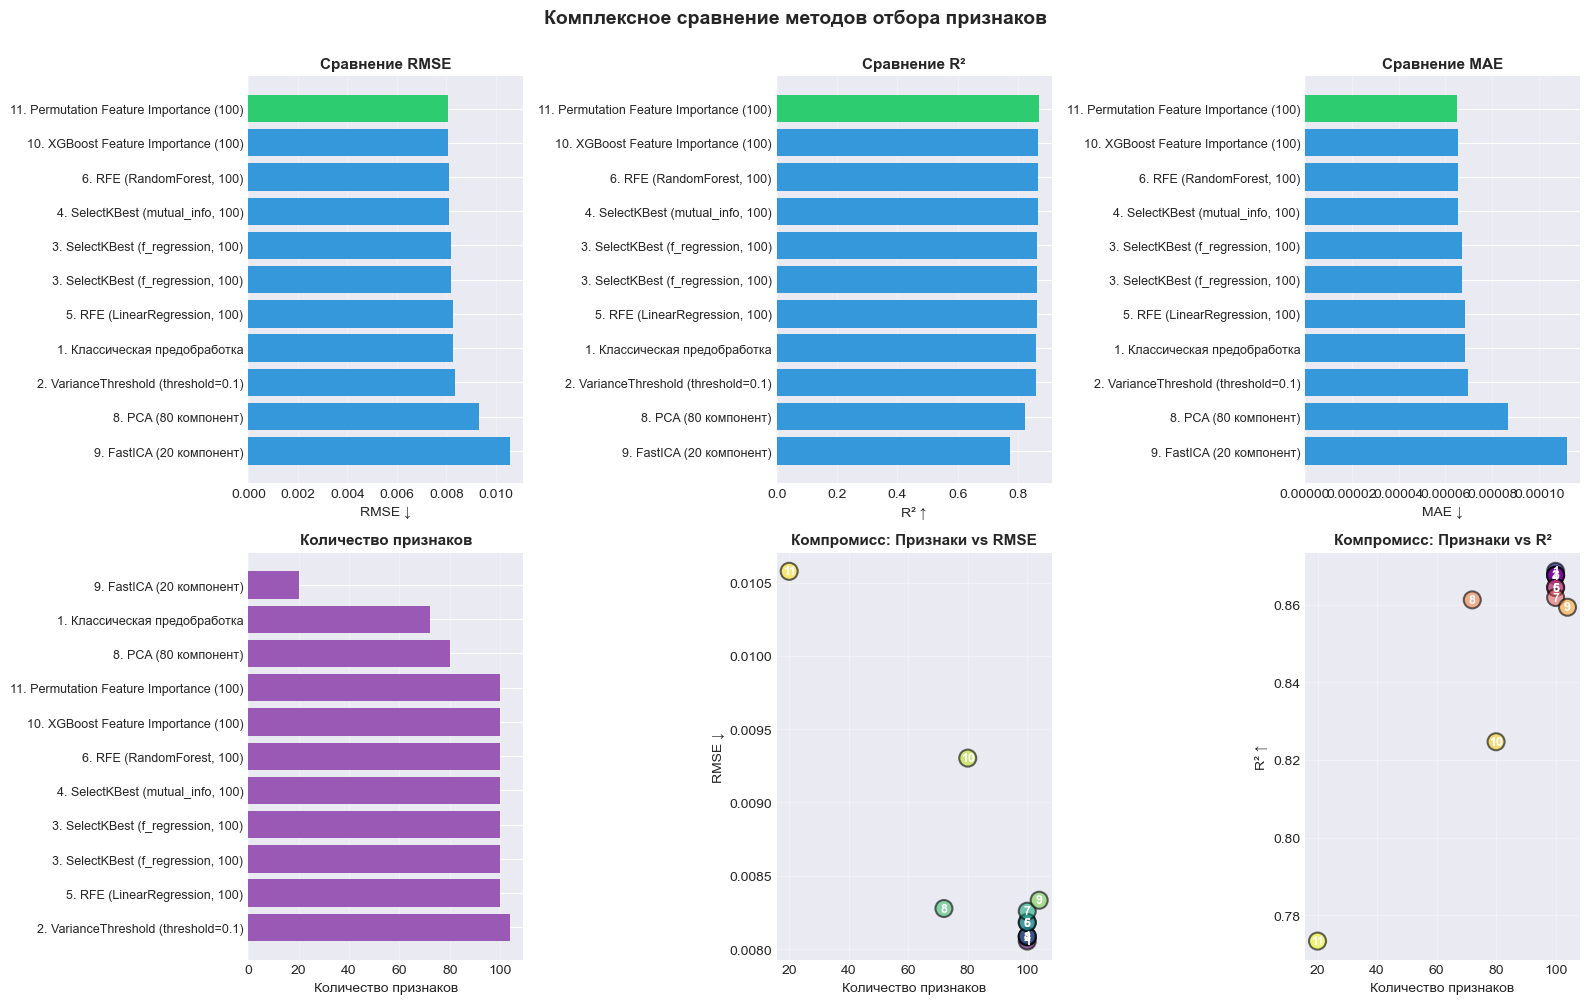

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(16, 10))

# 1. Сравнение RMSE
ax1 = plt.subplot(2, 3, 1)
results_sorted = results_df.sort_values('rmse')
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_sorted))]
ax1.barh(range(len(results_sorted)), results_sorted['rmse'], color=colors)
ax1.set_yticks(range(len(results_sorted)))
ax1.set_yticklabels(results_sorted['method'], fontsize=9)
ax1.set_xlabel('RMSE ↓', fontsize=10)
ax1.set_title('Сравнение RMSE', fontsize=11, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Сравнение R²
ax2 = plt.subplot(2, 3, 2)
results_sorted_r2 = results_df.sort_values('r2', ascending=False)
colors_r2 = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_sorted_r2))]
ax2.barh(range(len(results_sorted_r2)), results_sorted_r2['r2'], color=colors_r2)
ax2.set_yticks(range(len(results_sorted_r2)))
ax2.set_yticklabels(results_sorted_r2['method'], fontsize=9)
ax2.set_xlabel('R² ↑', fontsize=10)
ax2.set_title('Сравнение R²', fontsize=11, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# 3. Сравнение MAE
ax3 = plt.subplot(2, 3, 3)
results_sorted_mae = results_df.sort_values('mae')
colors_mae = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_sorted_mae))]
ax3.barh(range(len(results_sorted_mae)), results_sorted_mae['mae'], color=colors_mae)
ax3.set_yticks(range(len(results_sorted_mae)))
ax3.set_yticklabels(results_sorted_mae['method'], fontsize=9)
ax3.set_xlabel('MAE ↓', fontsize=10)
ax3.set_title('Сравнение MAE', fontsize=11, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# 4. Количество признаков
ax4 = plt.subplot(2, 3, 4)
results_sorted_feat = results_df.sort_values('n_features')
ax4.barh(range(len(results_sorted_feat)), results_sorted_feat['n_features'], color='#9b59b6')
ax4.set_yticks(range(len(results_sorted_feat)))
ax4.set_yticklabels(results_sorted_feat['method'], fontsize=9)
ax4.set_xlabel('Количество признаков', fontsize=10)
ax4.set_title('Количество признаков', fontsize=11, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

# 5. Признаки vs RMSE (scatter)
ax5 = plt.subplot(2, 3, 5)
scatter = ax5.scatter(results_df['n_features'], results_df['rmse'], 
                     s=150, alpha=0.6, c=range(len(results_df)), cmap='viridis', edgecolors='black', linewidth=1.5)
for idx, row in results_df.iterrows():
    ax5.annotate(f"{idx+1}", (row['n_features'], row['rmse']),
                fontsize=9, ha='center', va='center', fontweight='bold', color='white')
ax5.set_xlabel('Количество признаков', fontsize=10)
ax5.set_ylabel('RMSE ↓', fontsize=10)
ax5.set_title('Компромисс: Признаки vs RMSE', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Признаки vs R²
ax6 = plt.subplot(2, 3, 6)
scatter2 = ax6.scatter(results_df['n_features'], results_df['r2'], 
                      s=150, alpha=0.6, c=range(len(results_df)), cmap='plasma', edgecolors='black', linewidth=1.5)
for idx, row in results_df.iterrows():
    ax6.annotate(f"{idx+1}", (row['n_features'], row['r2']),
                fontsize=9, ha='center', va='center', fontweight='bold', color='white')
ax6.set_xlabel('Количество признаков', fontsize=10)
ax6.set_ylabel('R² ↑', fontsize=10)
ax6.set_title('Компромисс: Признаки vs R²', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.suptitle('Комплексное сравнение методов отбора признаков', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()